In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# inmport data
con = sqlite3.connect(r"C:\Users\user\Desktop\data analysis\churn_analysis\customer_churn.db")

sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(sql_query, con)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", con)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

con.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [4]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [5]:
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [6]:
df_db_customer.drop(columns=['interests','pincode'])

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [7]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [8]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [9]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [10]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07,NaN,None
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01,NaN,None


In [11]:
state_country=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
state_country

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [12]:
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country))


In [13]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [14]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [15]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

In [16]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [17]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [18]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [19]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [20]:
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [21]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(3), str(5

In [22]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

In [23]:
df.shape

(23, 22)

In [24]:
df_db_support['customerid'].nunique()

7

In [25]:
df_db_support['customerid'].size

9

In [26]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')     

In [27]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [28]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

In [29]:
df.shape

(21, 23)

In [30]:
df.to_csv('exported_churn.csv',index=False)

In [31]:
#churn rate
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='str')

In [32]:
# 1.churn rate

churn_rate=df['churn_flag'].mean()*100
print("churn_rate=",round(churn_rate,2),"%")

churn_rate= 28.57 %


In [33]:
# 2.Retention rate

retention = 100-churn_rate
print("retention=",retention)

retention= 71.42857142857143


In [34]:
# 3. charn by plan type

churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [35]:
# ARPU : avg revenue per user

arpu = df['monthly_charges'].mean().round(2)
print(arpu)

18.85


In [36]:
# average customer tenure
today=pd.Timestamp.today()
df['tenure_days']=np.where(df['cancellation_date'].notna(),
                           (df['cancellation_date']-df['subscription_start_date']).dt.days,
                           (today-df['subscription_start_date']).dt.days)
avg_tenure=df['tenure_days'].mean()
print(round(avg_tenure,2))

1538.71


In [37]:
#revenue lost from churn users

revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print(revenue_at_risk)

73.94


In [38]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1


In [39]:
#esclation rate

escalation_rate=(df['escalations']=='Y').mean()*100
print(escalation_rate)
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print(round(avg_complaints,2))

19.047619047619047
0.43


In [40]:
#correlation escalation

#corr_df=df[['escalations','churn_flag']].dropna()
#df['escalations']=np.where(df['escalations']=='Y',1,0)
#correlation=corr_df['escalations'].corr(df['churn_flag'])
#print(correlation)

In [41]:
df['escalations'].value_counts()

escalations
Y    4
N    3
Name: count, dtype: int64

In [42]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN,2009.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,NaN,None,2024-08-28,Y,10.0,2.0,1501.0


In [43]:
#correlation escalation

# Convert Y/N to 1/0
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

# Select required columns
corr_df = df[['escalations', 'churn_flag']].dropna()

# Calculate correlation
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation:", round(correlation, 2))

Correlation: 0.47


In [44]:
#churn risk
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50)&(df['churn_score']<=70),
    (df['churn_score'])>=70]
choices=['low','med','high']
df['churn_risk']=np.select(conditions,choices,default='unknown')

In [45]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [46]:
#matplot
#copy the dataFrame
df_visual=df.copy()

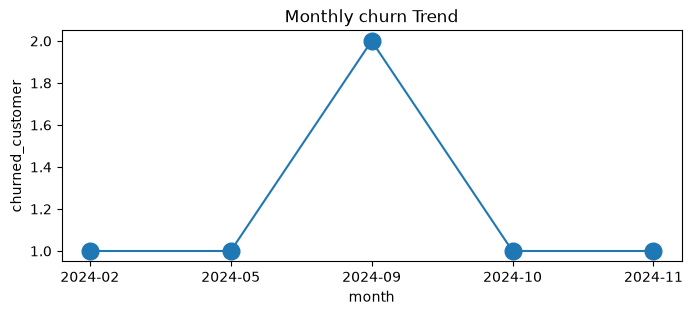

In [47]:
#monthly churn trend
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'),churn_trend.values,markersize=12,marker='o')
plt.title('Monthly churn Trend')
plt.xlabel('month')
plt.ylabel('churned_customer')
plt.show()

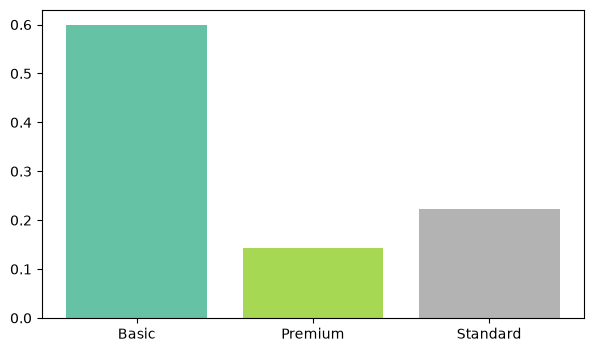

In [48]:
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))

#dynamic coloring cm=colormap set=color palate
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

<Figure size 700x400 with 0 Axes>

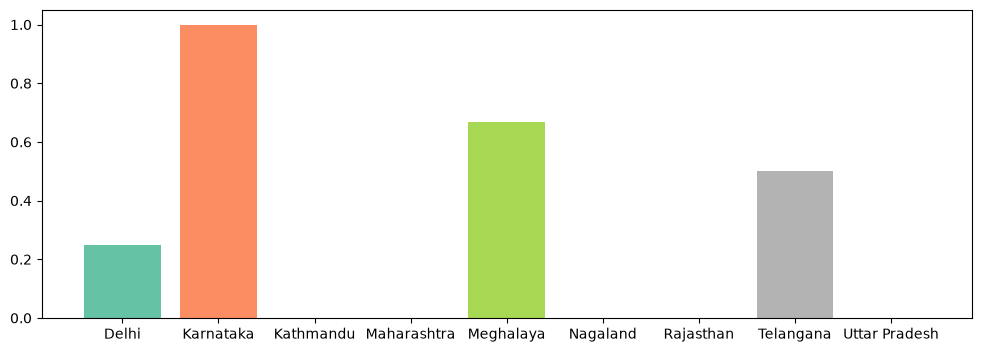

In [49]:
churn_plan=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(7,4))

#dynamic coloring cm=colormap set=color palate
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

In [50]:
#seaborn

In [51]:
#encoding string to numeric

#df_visual['escalations'] = df_visual['escalations'].fillna(0).astype(int)

df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
categorial_cols=['plan_type','contract_type','churn_risk']
for col in categorial_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes
    

In [52]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,NaN
1,1,0,91,1,0,1.0
2,0,1,34,0,1,NaN
3,1,0,8,0,1,NaN
4,2,1,88,1,0,1.0


<Axes: >

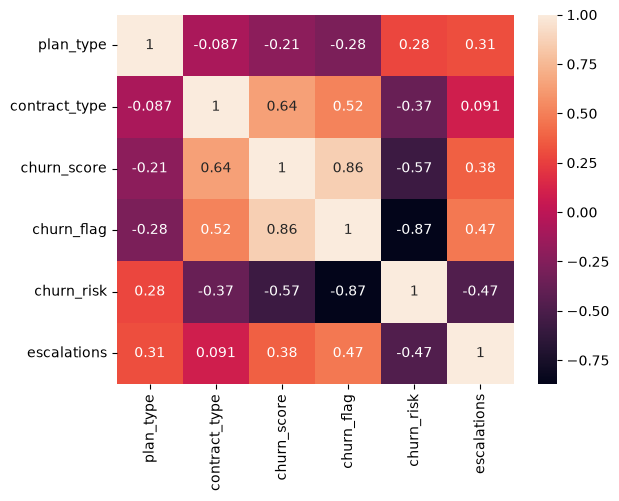

In [53]:
sns.heatmap(df_encoded.corr(),annot=True)

In [54]:
#correct method

df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
order_mappings={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),
                                   categories=order,ordered=True).codes

#This dictionary tells pandas:

# What order do I want these categories to have?

# plan_type
# 'plan_type': ['Basic', 'Standard', 'Premium']

# You are saying:

# Basic < Standard < Premium

# So you want:

# Basic     → 0
# Standard  → 1
# Premium   → 2
# contract_type
# 'contract_type': ['Monthly', 'Annual']

# You want:

# Monthly → 0
# Annual  → 1

<Axes: >

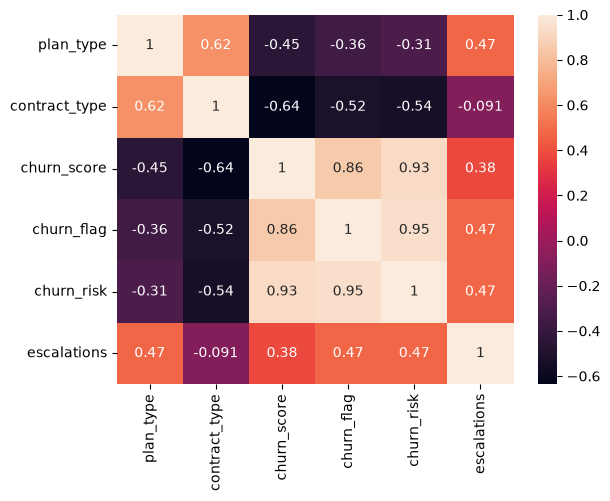

In [55]:
sns.heatmap(df_encoded.corr(),annot=True)

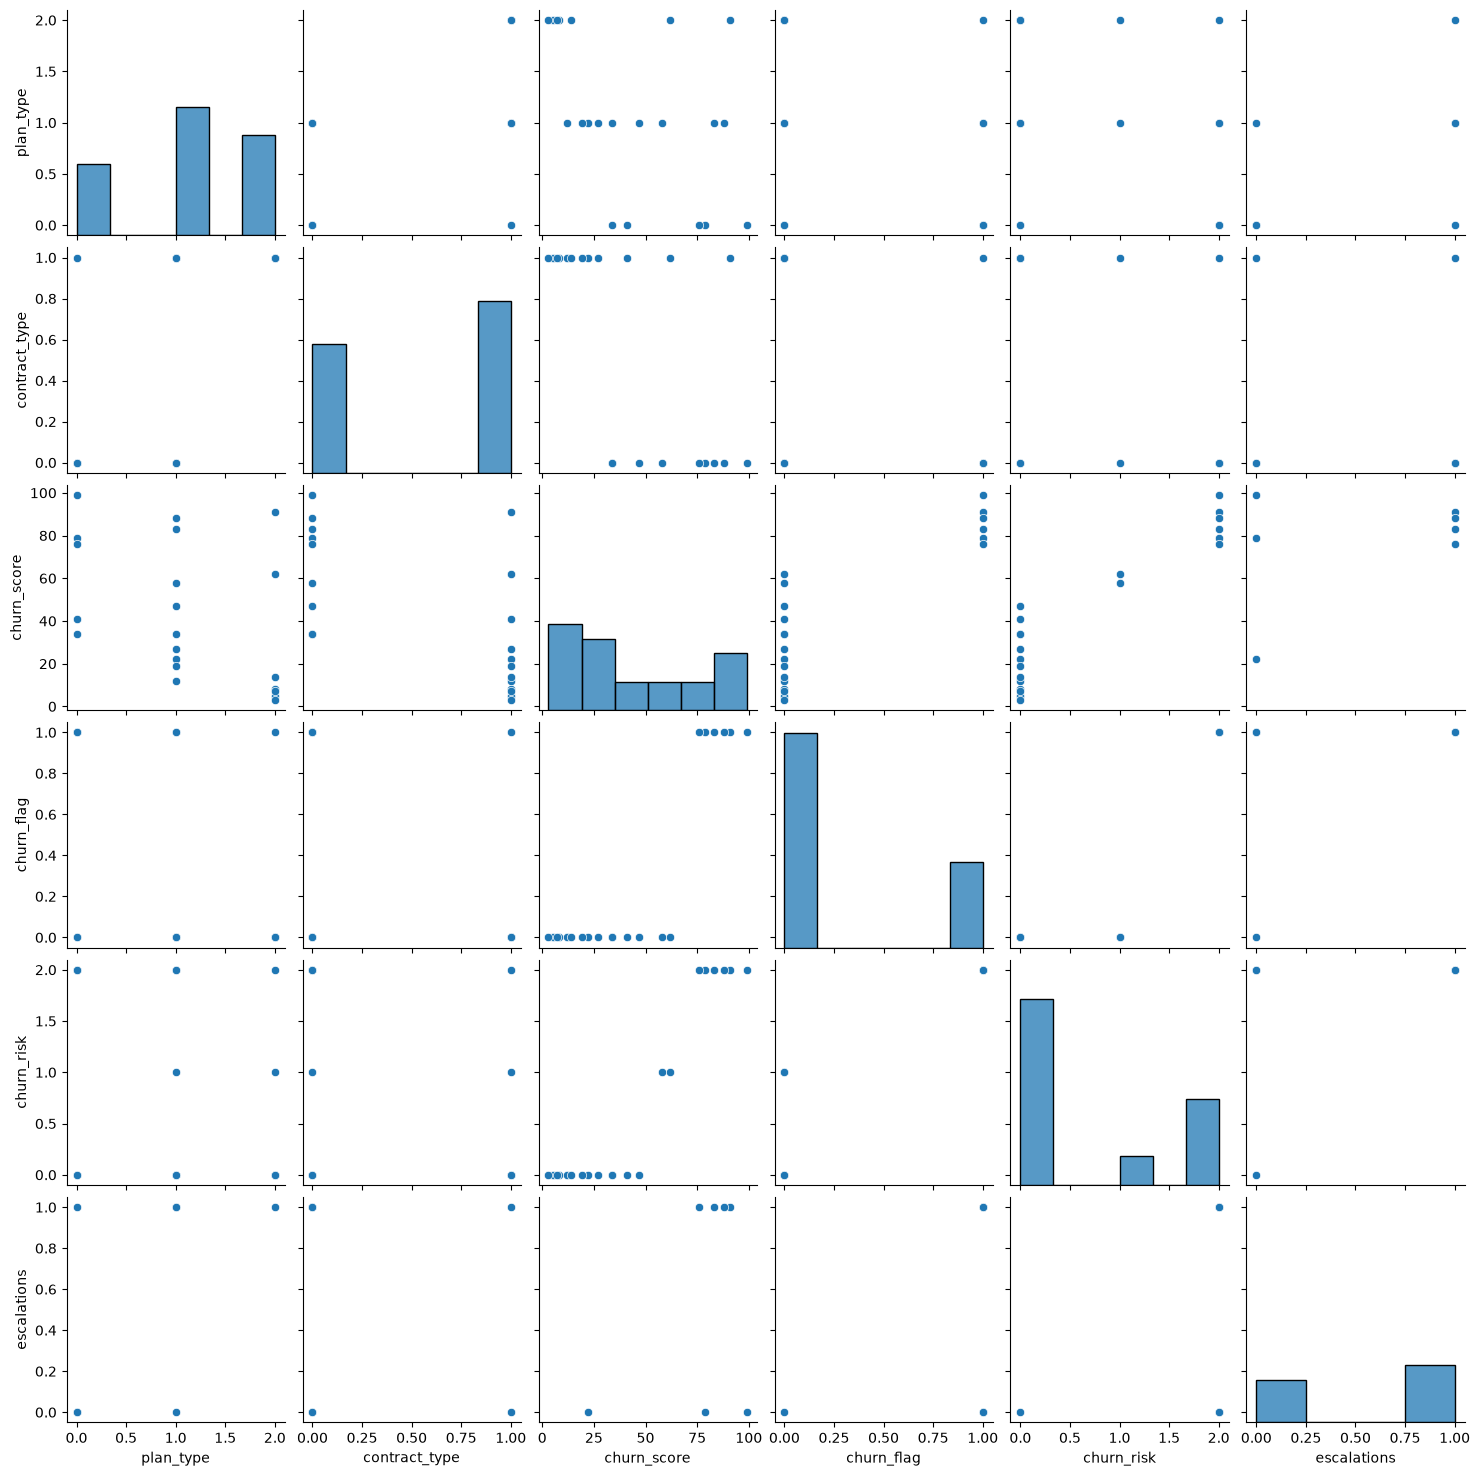

In [56]:
sns.pairplot(df_encoded)

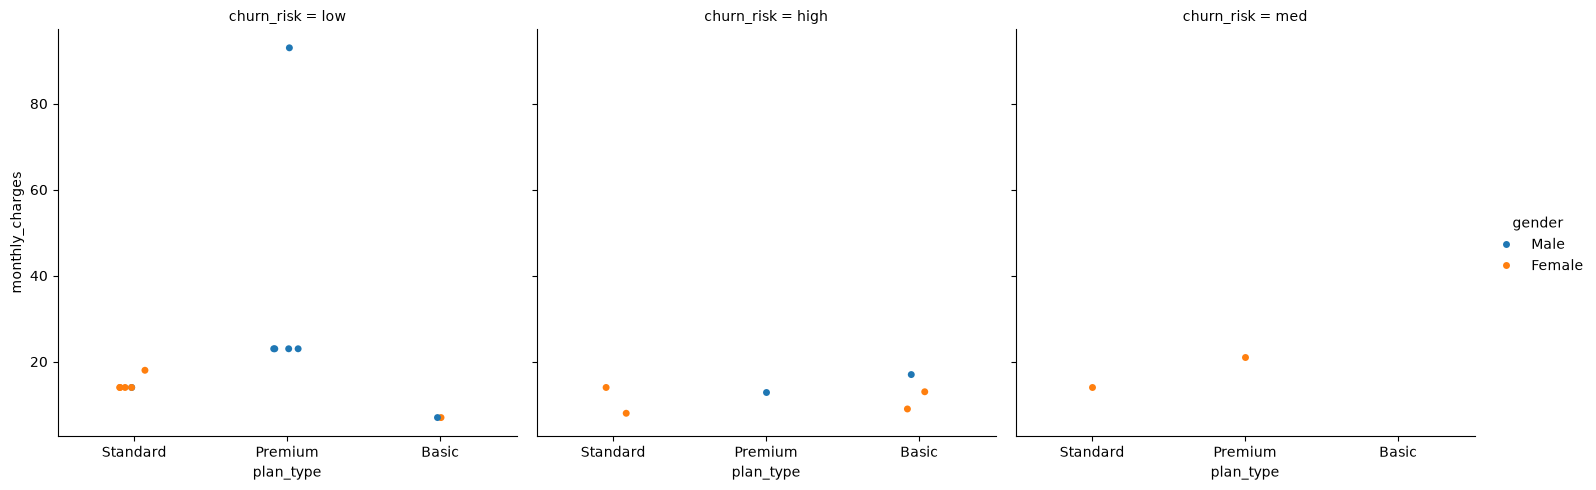

In [57]:
sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)

In [58]:
#pivot table

pd.pivot_table(df_visual,values='churn_flag',index='plan_type',aggfunc='mean').reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [59]:
pd.pivot_table(df_visual,
              index='plan_type',
              values=['monthly_charges','customerid','churn_flag'],
              aggfunc={'monthly_charges':'sum',
                      'customerid':'nunique',
                      'churn_flag':'mean'}).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [69]:
conn = sqlite3.connect("test_database.sqlite")

conn.execute("""CREATE TABLE IF NOT EXISTS users(
    first_name TEXT,
    country TEXT,
    budget INTEGER
)""")

conn.commit()

In [70]:
# Clear existing data
cursor = conn.cursor()

cursor.execute("DELETE FROM users")

conn.commit()

print("Table cleared successfully")

Table cleared successfully


In [71]:
#insert data
cursor=conn.cursor()

cursor.execute("""INSERT into USERS values
    ('rishav','india',5000),
    ('kumar','germany',2500),
    ('rai','india',5000)""")

conn.commit()

In [72]:
#check inserted data in table

conn=sqlite3.connect('test_database.sqlite')
query="""SELECT * FROM users"""

df_results=pd.read_sql(query,conn)
df_results.head(10)

,first_name,country,budget
0,rishav,india,5000
1,kumar,germany,2500
2,rai,india,5000
